# NBA Model — Ablation Test: ELO Feature Redundancy

**Goal:** Find the optimal ELO feature configuration by removing redundant features  
**Key finding:** `implied_prob_home` is ELO-derived (NOT betting odds) — no leakage  
**Real problem:** 7 ELO features in model, several are mathematically redundant  

---
### What we are testing
| Experiment | ELO Features Removed | Question answered |
|---|---|---|
| E0 — Current | None (control) | Reproduce training.ipynb baseline |
| E1 — Remove Duplicate | `elo_difference` | Does removing the exact duplicate of `elo_diff` help? |
| E2 — Remove Implied | `elo_difference` + `implied_prob_home` | Does the non-linear ELO transform add value? |
| E3 — Raw ELO Only | `elo_difference` + `implied_prob_home` + `elo_home` + `elo_away` | Does keeping only diff + rolling work? |
| E4 — Prob Only | `elo_difference` + `elo_diff` + `elo_home` + `elo_away` | Does probability beat raw ratings? |

## Cell 1 — Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'XGBoost : {xgb.__version__}')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')
print('All imports OK.')

XGBoost : 3.2.0
Pandas  : 3.0.2
NumPy   : 2.4.4
All imports OK.


## Cell 2 — Load Data

In [2]:
MASTER_PATH = '../data/master_dataset.csv'

master = pd.read_csv(MASTER_PATH, parse_dates=['game_date'])
master = master.sort_values('game_date').reset_index(drop=True)

print(f'Loaded  : {master.shape[0]:,} rows x {master.shape[1]} columns')
print(f'Dates   : {master["game_date"].min().date()} to {master["game_date"].max().date()}')
print(f'Seasons : {sorted(master["season"].unique())}')

# Confirm target column exists
assert 'home_win' in master.columns, 'ERROR: home_win column missing'
print(f'Target  : home_win | home win rate = {master["home_win"].mean():.3f}')

Loaded  : 29,575 rows x 63 columns
Dates   : 2003-10-31 to 2025-02-12
Seasons : [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Target  : home_win | home win rate = 0.585


## Cell 3 — Train / Validation / Test Split
> Must match training.ipynb exactly: 25929 / 2767 / 879

In [3]:
TRAIN_END   = 2021
VALID_START = 2022
VALID_END   = 2023
TEST_START  = 2024

train_df = master[master['season'] <= TRAIN_END].copy()
valid_df = master[(master['season'] >= VALID_START) & (master['season'] <= VALID_END)].copy()
test_df  = master[master['season'] >= TEST_START].copy()

print(f'Train : {len(train_df):,} rows | seasons 2003-{TRAIN_END}')
print(f'Valid : {len(valid_df):,} rows | seasons {VALID_START}-{VALID_END}')
print(f'Test  : {len(test_df):,} rows  | season  {TEST_START}+')

# Hard assertions — must match training.ipynb
assert len(train_df) == 25929, f'Train size mismatch: got {len(train_df)}, expected 25929'
assert len(valid_df) == 2767,  f'Valid size mismatch: got {len(valid_df)}, expected 2767'
assert len(test_df)  == 879,   f'Test  size mismatch: got {len(test_df)}, expected 879'
print('\nSplit sizes VERIFIED — match training.ipynb exactly.')

Train : 25,929 rows | seasons 2003-2021
Valid : 2,767 rows | seasons 2022-2023
Test  : 879 rows  | season  2024+

Split sizes VERIFIED — match training.ipynb exactly.


## Cell 4 — Feature Engineering (Exact Replica of training.ipynb)

In [4]:
# Exact same DROP_COLS as training.ipynb
DROP_COLS    = ['game_id', 'game_date', 'season', 'home_team_id', 'away_team_id',
                'home_win', 'line_movement']
FEATURE_COLS = [c for c in master.columns if c not in DROP_COLS]

# Exact same differential feature function as training.ipynb
def add_differential_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    diff_pairs = [
        ('elo_home',                         'elo_away'),
        ('net_rating_home',                  'net_rating_away'),
        ('offensive_rating_home',            'offensive_rating_away'),
        ('defensive_rating_home',            'defensive_rating_away'),
        ('last_5_win_rate_home',             'last_5_win_rate_away'),
        ('last_10_win_rate_home',            'last_10_win_rate_away'),
        ('ppg_10_home',                      'ppg_10_away'),
        ('rest_days_home',                   'rest_days_away'),
        ('fatigue_load_index_home',          'fatigue_load_index_away'),
        ('turnovers_per_game_home',          'turnovers_per_game_away'),
        ('player_impact_estimate_home',      'player_impact_estimate_away'),
        ('injured_count_home',               'injured_count_away'),
        ('coaching_adaptability_score_home', 'coaching_adaptability_score_away'),
    ]
    for col_a, col_b in diff_pairs:
        if col_a in df.columns and col_b in df.columns:
            name = col_a.replace('_home', '') + '_diff'
            df[name] = df[col_a] - df[col_b]
    return df

# Apply to all splits
master   = add_differential_features(master)
train_df = add_differential_features(train_df)
valid_df = add_differential_features(valid_df)
test_df  = add_differential_features(test_df)

# Build ALL_FEATURES with deduplication fix (from training.ipynb fix)
DIFF_FEATURES = [c for c in master.columns if c.endswith('_diff')]
ALL_FEATURES  = list(dict.fromkeys(FEATURE_COLS + DIFF_FEATURES))

# Remove low-variance features
var_threshold = 1e-4
low_var = [c for c in ALL_FEATURES
           if c in train_df.columns and train_df[c].var() < var_threshold]
ALL_FEATURES = [c for c in ALL_FEATURES if c not in low_var]

print(f'Base features     : {len(FEATURE_COLS)}')
print(f'Diff features     : {len(DIFF_FEATURES)}')
print(f'Final features    : {len(ALL_FEATURES)}')

# Verify
assert len(ALL_FEATURES) == 69, f'Feature count mismatch: got {len(ALL_FEATURES)}, expected 69'
print('Feature count VERIFIED — 69 features match training.ipynb')

# Show ELO features
elo_cols = [f for f in ALL_FEATURES if 'elo' in f.lower() or 'implied' in f.lower()]
print(f'\nELO-related features ({len(elo_cols)} total):')
for c in elo_cols:
    print(f'  {c}')

Base features     : 56
Diff features     : 14
Final features    : 69
Feature count VERIFIED — 69 features match training.ipynb

ELO-related features (7 total):
  elo_home
  elo_away
  elo_difference
  elo_rolling_five_home
  elo_rolling_five_away
  implied_prob_home
  elo_diff


## Cell 5 — Define the 5 Experiment Feature Sets

In [5]:
# E0: Current — all features including known duplicate (control)
FEATURES_E0 = ALL_FEATURES.copy()

# E1: Remove elo_difference (exact duplicate of elo_diff)
FEATURES_E1 = [f for f in ALL_FEATURES if f != 'elo_difference']

# E2: Remove elo_difference AND implied_prob_home (non-linear ELO transform)
FEATURES_E2 = [f for f in ALL_FEATURES
               if f not in ('elo_difference', 'implied_prob_home')]

# E3: Remove duplicate + implied_prob + raw elo_home/elo_away
#     Keep: elo_diff, elo_rolling_five_home, elo_rolling_five_away
FEATURES_E3 = [f for f in ALL_FEATURES
               if f not in ('elo_difference', 'implied_prob_home',
                            'elo_home', 'elo_away')]

# E4: Remove duplicate + elo_diff + raw elo_home/elo_away
#     Keep: implied_prob_home, elo_rolling_five_home, elo_rolling_five_away
FEATURES_E4 = [f for f in ALL_FEATURES
               if f not in ('elo_difference', 'elo_diff',
                            'elo_home', 'elo_away')]

experiments = {
    'E0_current'        : FEATURES_E0,
    'E1_remove_dup'     : FEATURES_E1,
    'E2_remove_implied' : FEATURES_E2,
    'E3_raw_elo_only'   : FEATURES_E3,
    'E4_prob_only'      : FEATURES_E4,
}

print('Experiment configurations:')
print(f'{"Experiment":<22} {"Features":>10} {"ELO cols kept"}')
print('-' * 75)
for name, feats in experiments.items():
    elo_in = [f for f in feats if 'elo' in f.lower() or 'implied' in f.lower()]
    print(f'{name:<22} {len(feats):>10}   {elo_in}')

Experiment configurations:
Experiment               Features ELO cols kept
---------------------------------------------------------------------------
E0_current                     69   ['elo_home', 'elo_away', 'elo_difference', 'elo_rolling_five_home', 'elo_rolling_five_away', 'implied_prob_home', 'elo_diff']
E1_remove_dup                  68   ['elo_home', 'elo_away', 'elo_rolling_five_home', 'elo_rolling_five_away', 'implied_prob_home', 'elo_diff']
E2_remove_implied              67   ['elo_home', 'elo_away', 'elo_rolling_five_home', 'elo_rolling_five_away', 'elo_diff']
E3_raw_elo_only                65   ['elo_rolling_five_home', 'elo_rolling_five_away', 'elo_diff']
E4_prob_only                   65   ['elo_rolling_five_home', 'elo_rolling_five_away', 'implied_prob_home']


## Cell 6 — Helper Functions: Build Splits + Train + Evaluate

In [6]:
def build_splits(feature_list):
    """Build train/valid/test X matrices. Validates no duplicates or NaNs."""
    missing = [f for f in feature_list if f not in train_df.columns]
    if missing:
        raise ValueError(f'Features missing from train_df: {missing}')

    X_tr = train_df[feature_list].fillna(0)
    y_tr = train_df['home_win']
    X_va = valid_df[feature_list].fillna(0)
    y_va = valid_df['home_win']
    X_te = test_df[feature_list].fillna(0)
    y_te = test_df['home_win']

    # Safety checks
    assert X_tr.columns.duplicated().sum() == 0, 'Duplicate columns in X_train!'
    assert X_tr.isnull().sum().sum()        == 0, 'NaN values remain in X_train!'
    assert X_va.isnull().sum().sum()        == 0, 'NaN values remain in X_valid!'
    assert X_te.isnull().sum().sum()        == 0, 'NaN values remain in X_test!'

    return X_tr, y_tr, X_va, y_va, X_te, y_te


# Exact best_params from training.ipynb RandomizedSearchCV result
BEST_PARAMS = {
    'subsample'        : 0.8,
    'reg_lambda'       : 0.5,
    'reg_alpha'        : 0.01,
    'n_estimators'     : 2000,
    'min_child_weight' : 3,
    'max_depth'        : 4,
    'learning_rate'    : 0.01,
    'gamma'            : 0.5,
    'colsample_bytree' : 0.8,
}


def train_experiment(X_tr, y_tr, X_va, y_va, name):
    """Train one XGBoost model with fixed params. Returns fitted model."""
    print(f'\n{"-"*55}')
    print(f'  Training: {name}  ({X_tr.shape[1]} features)')
    print(f'{"-"*55}')
    model = xgb.XGBClassifier(
        **BEST_PARAMS,
        eval_metric           = 'logloss',
        early_stopping_rounds = 40,
        use_label_encoder     = False,
        random_state          = RANDOM_STATE,
        n_jobs                = -1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set = [(X_tr, y_tr), (X_va, y_va)],
        verbose  = 200,
    )
    print(f'  Best iteration: {model.best_iteration}')
    return model


def evaluate_experiment(model, X_te, y_te, name):
    """Evaluate on test set. Returns metrics dict."""
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= 0.5).astype(int)

    report = classification_report(
        y_te, preds,
        target_names = ['Away Win', 'Home Win'],
        output_dict  = True
    )

    metrics = {
        'experiment'  : name,
        'n_features'  : X_te.shape[1],
        'best_iter'   : model.best_iteration,
        'accuracy'    : accuracy_score(y_te, preds),
        'roc_auc'     : roc_auc_score(y_te, probs),
        'log_loss'    : log_loss(y_te, probs),
        'brier'       : brier_score_loss(y_te, probs),
        'away_recall' : report['Away Win']['recall'],
        'home_recall' : report['Home Win']['recall'],
        'away_prec'   : report['Away Win']['precision'],
        'home_prec'   : report['Home Win']['precision'],
    }

    print(f'\n  Results — {name}')
    print(f'  Accuracy    : {metrics["accuracy"]:.4f}')
    print(f'  ROC-AUC     : {metrics["roc_auc"]:.4f}')
    print(f'  Log Loss    : {metrics["log_loss"]:.4f}')
    print(f'  Brier       : {metrics["brier"]:.4f}')
    print(f'  Away Recall : {metrics["away_recall"]:.4f}')
    print(f'  Home Recall : {metrics["home_recall"]:.4f}')
    return metrics


print('Helper functions defined: build_splits(), train_experiment(), evaluate_experiment()')

Helper functions defined: build_splits(), train_experiment(), evaluate_experiment()


## Cell 7 — Run All 5 Experiments
> This cell trains 5 models. Estimated time: 25–40 minutes total.

In [7]:
import time

all_results   = []
trained_models = {}

total_start = time.time()

for exp_name, feature_list in experiments.items():
    t0 = time.time()

    # Build splits
    X_tr, y_tr, X_va, y_va, X_te, y_te = build_splits(feature_list)

    # Train
    model = train_experiment(X_tr, y_tr, X_va, y_va, exp_name)

    # Evaluate
    metrics = evaluate_experiment(model, X_te, y_te, exp_name)
    metrics['train_time_sec'] = round(time.time() - t0, 1)

    # Store
    all_results.append(metrics)
    trained_models[exp_name] = model

    print(f'  Time: {metrics["train_time_sec"]}s')

total_time = round(time.time() - total_start, 1)
print(f'\n\nAll 5 experiments complete. Total time: {total_time}s')


-------------------------------------------------------
  Training: E0_current  (69 features)
-------------------------------------------------------


[0]	validation_0-logloss:0.67602	validation_1-logloss:0.68607


[200]	validation_0-logloss:0.60030	validation_1-logloss:0.62251


[400]	validation_0-logloss:0.58767	validation_1-logloss:0.61635


[600]	validation_0-logloss:0.57951	validation_1-logloss:0.61489


...

[0]	validation_0-logloss:0.67598	validation_1-logloss:0.68598


[200]	validation_0-logloss:0.60027	validation_1-logloss:0.62271


[400]	validation_0-logloss:0.58765	validation_1-logloss:0.61629


[525]	validation_0-logloss:0.58251	validation_1-logloss:0.61578


  Best iteration: 485

  Results — E4_prob_only
  Accuracy    : 0.6416
  ROC-AUC     : 0.7063
  Log Loss    : 0.6159
  Brier       : 0.2150
  Away Recall : 0.4785
  Home Recall : 0.7748
  Time: 6.2s


All 5 experiments complete. Total time: 40.7s


## Cell 8 — Results Comparison Table

In [8]:
results_df = pd.DataFrame(all_results).set_index('experiment')

# Compute deltas vs E0 baseline
e0 = results_df.loc['E0_current']
results_df['acc_delta'] = results_df['accuracy'] - e0['accuracy']
results_df['auc_delta'] = results_df['roc_auc']  - e0['roc_auc']
results_df['ll_delta']  = results_df['log_loss'] - e0['log_loss']

# Display columns
display_cols = ['n_features', 'accuracy', 'acc_delta', 'roc_auc',
                'auc_delta', 'log_loss', 'll_delta', 'brier',
                'away_recall', 'home_recall', 'best_iter']

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print('\n' + '='*100)
print('  ABLATION TEST — COMPLETE RESULTS')
print('='*100)
print(results_df[display_cols].to_string())
print('='*100)

best_auc_exp = results_df['roc_auc'].idxmax()
best_acc_exp = results_df['accuracy'].idxmax()
print(f'\nBest by ROC-AUC  : {best_auc_exp} ({results_df.loc[best_auc_exp, "roc_auc"]:.4f})')
print(f'Best by Accuracy : {best_acc_exp} ({results_df.loc[best_acc_exp, "accuracy"]:.4f})')
print(f'Best by Log Loss : {results_df["log_loss"].idxmin()} ({results_df["log_loss"].min():.4f})')


  ABLATION TEST — COMPLETE RESULTS
                   n_features  accuracy  acc_delta  roc_auc  auc_delta  log_loss  ll_delta  brier  away_recall  home_recall  best_iter
experiment                                                                                                                            
E0_current                 69    0.6382     0.0000   0.7092     0.0000    0.6141    0.0000 0.2141       0.4937       0.7562        746
E1_remove_dup              68    0.6439     0.0057   0.7069    -0.0022    0.6153    0.0013 0.2147       0.4911       0.7686        637
E2_remove_implied          67    0.6405     0.0023   0.7074    -0.0017    0.6152    0.0011 0.2146       0.4987       0.7562        708
E3_raw_elo_only            65    0.6405     0.0023   0.7065    -0.0026    0.6160    0.0019 0.2150       0.4911       0.7624        626
E4_prob_only               65    0.6416     0.0034   0.7063    -0.0029    0.6159    0.0019 0.2150       0.4785       0.7748        485

Best by ROC-AUC  :

## Cell 9 — Visualisation: All Metrics Side by Side

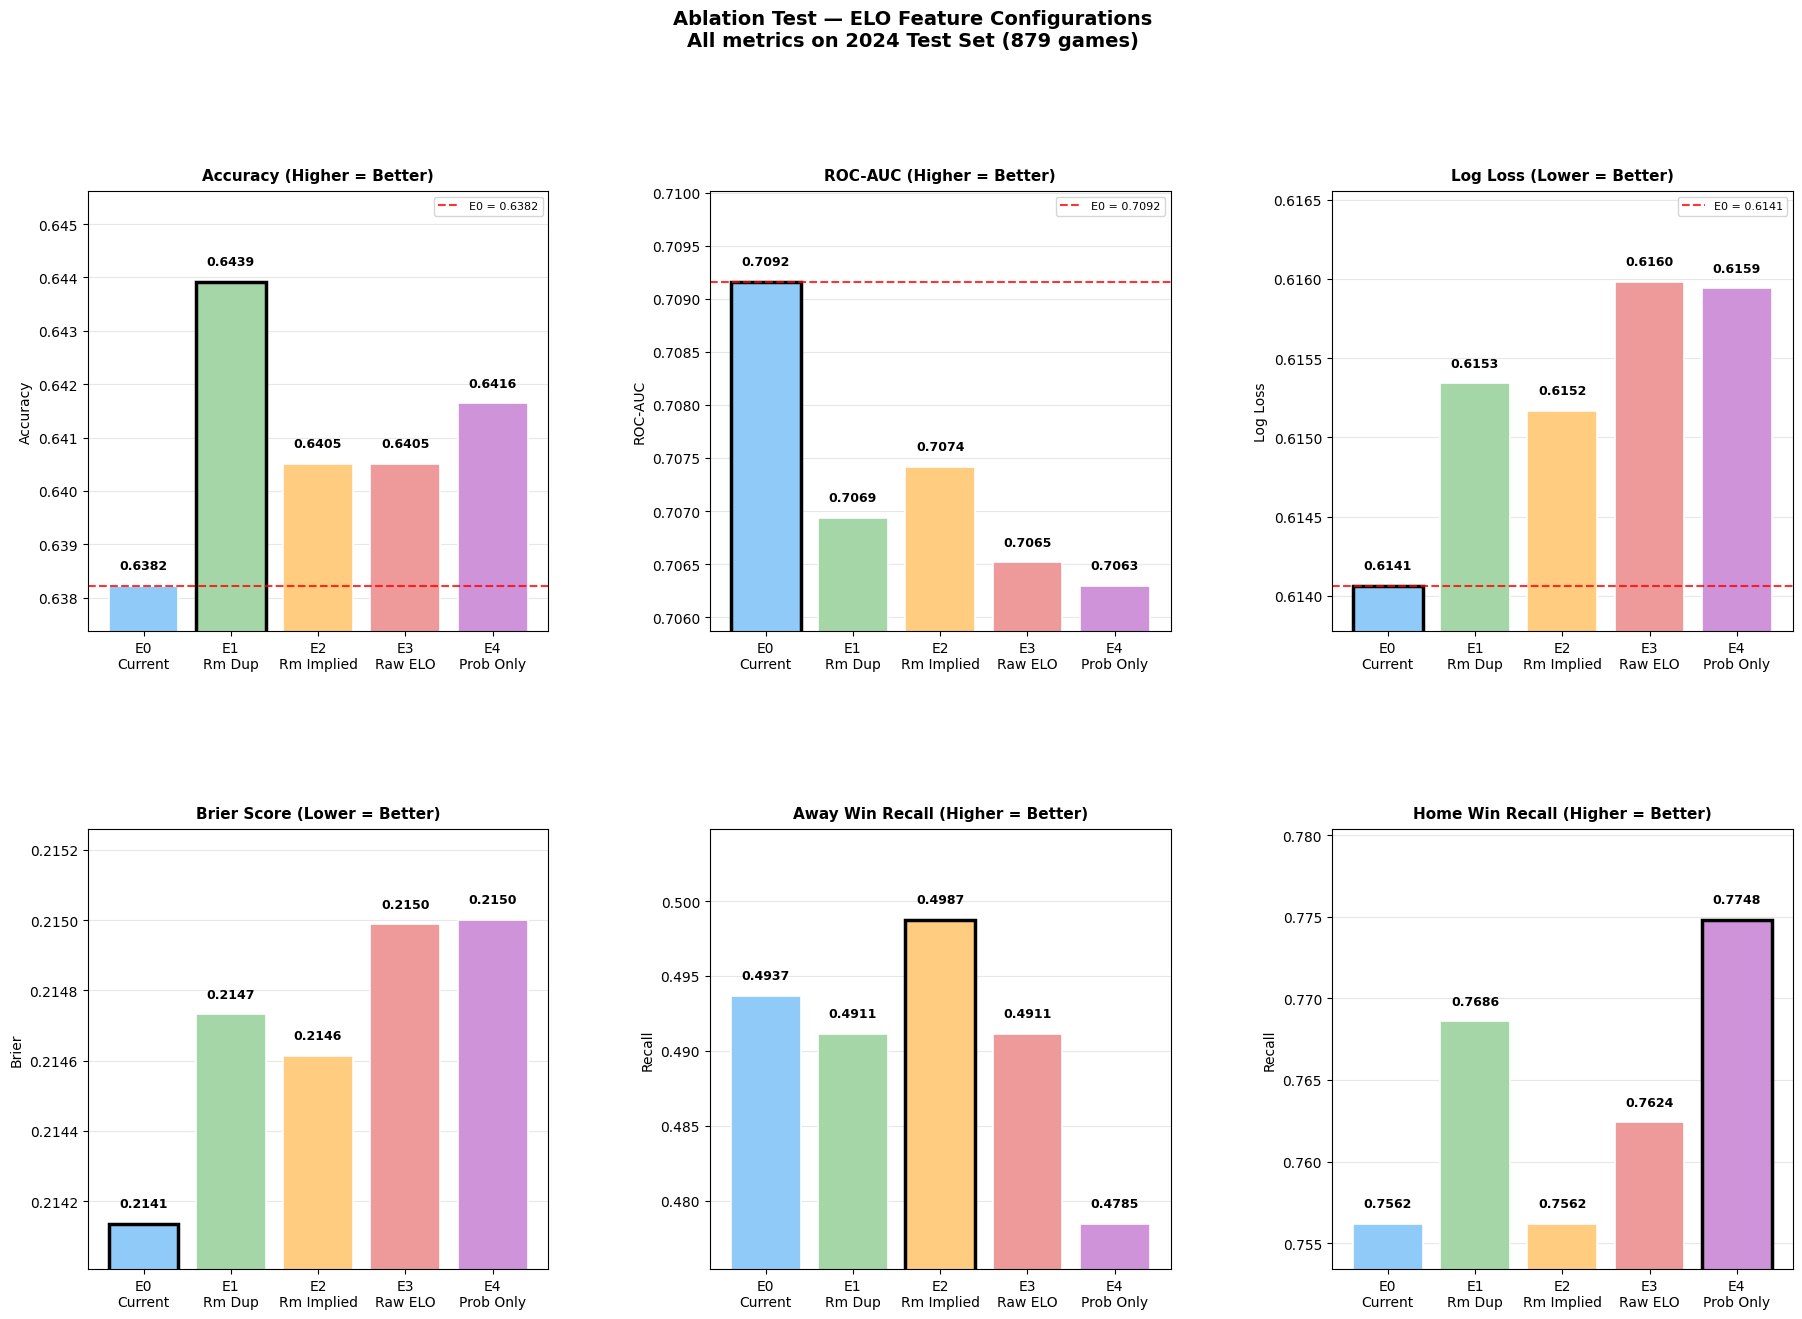

Chart saved to ../reports/ablation_elo_features.png


In [9]:
exp_labels  = list(results_df.index)
short_labels = ['E0\nCurrent', 'E1\nRm Dup', 'E2\nRm Implied',
                'E3\nRaw ELO', 'E4\nProb Only']
colors = ['#90CAF9', '#A5D6A7', '#FFCC80', '#EF9A9A', '#CE93D8']

fig = plt.figure(figsize=(22, 14))
fig.suptitle('Ablation Test — ELO Feature Configurations\nAll metrics on 2024 Test Set (879 games)',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

def bar_panel(ax, values, title, ylabel, lower_better=False, add_baseline=None):
    bars = ax.bar(short_labels, values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel, fontsize=10)
    if add_baseline is not None:
        ax.axhline(add_baseline, color='red', linestyle='--', linewidth=1.5,
                   label=f'E0 = {add_baseline:.4f}', alpha=0.8)
        ax.legend(fontsize=8)
    y_min, y_max = min(values), max(values)
    pad = (y_max - y_min) * 0.15 if y_max != y_min else 0.001
    ax.set_ylim(y_min - pad, y_max + pad * 2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + pad * 0.3,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Highlight best bar
    best_idx = int(np.argmin(values) if lower_better else np.argmax(values))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

e0_acc = results_df.loc['E0_current', 'accuracy']
e0_auc = results_df.loc['E0_current', 'roc_auc']
e0_ll  = results_df.loc['E0_current', 'log_loss']

bar_panel(fig.add_subplot(gs[0, 0]), results_df['accuracy'].values,
          'Accuracy (Higher = Better)', 'Accuracy', add_baseline=e0_acc)

bar_panel(fig.add_subplot(gs[0, 1]), results_df['roc_auc'].values,
          'ROC-AUC (Higher = Better)', 'ROC-AUC', add_baseline=e0_auc)

bar_panel(fig.add_subplot(gs[0, 2]), results_df['log_loss'].values,
          'Log Loss (Lower = Better)', 'Log Loss', lower_better=True, add_baseline=e0_ll)

bar_panel(fig.add_subplot(gs[1, 0]), results_df['brier'].values,
          'Brier Score (Lower = Better)', 'Brier', lower_better=True)

bar_panel(fig.add_subplot(gs[1, 1]), results_df['away_recall'].values,
          'Away Win Recall (Higher = Better)', 'Recall')

bar_panel(fig.add_subplot(gs[1, 2]), results_df['home_recall'].values,
          'Home Win Recall (Higher = Better)', 'Recall')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/ablation_elo_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to ../reports/ablation_elo_features.png')

## Cell 10 — Feature Count vs AUC Scatter Plot

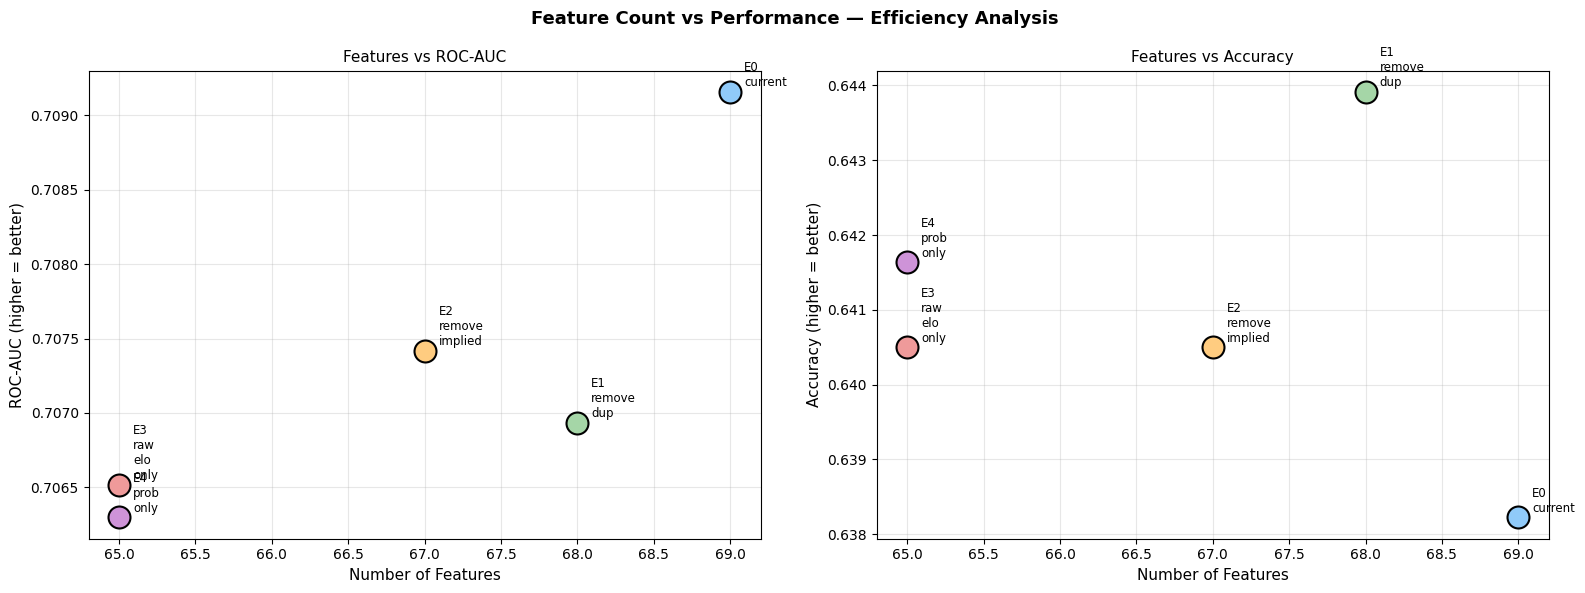

Efficiency chart saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Count vs Performance — Efficiency Analysis', fontsize=13, fontweight='bold')

for ax, metric, label, lower_better in [
    (axes[0], 'roc_auc',  'ROC-AUC (higher = better)', False),
    (axes[1], 'accuracy', 'Accuracy (higher = better)', False),
]:
    for i, (name, row) in enumerate(results_df.iterrows()):
        ax.scatter(row['n_features'], row[metric], s=250,
                   color=colors[i], edgecolors='black', linewidths=1.5, zorder=5)
        ax.annotate(name.replace('_', '\n'),
                    (row['n_features'], row[metric]),
                    textcoords='offset points', xytext=(10, 4),
                    fontsize=8.5, ha='left')
    ax.set_xlabel('Number of Features', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'Features vs {label.split(" ")[0]}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/ablation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Efficiency chart saved.')

## Cell 11 — Delta Heatmap (Change vs E0 Baseline)

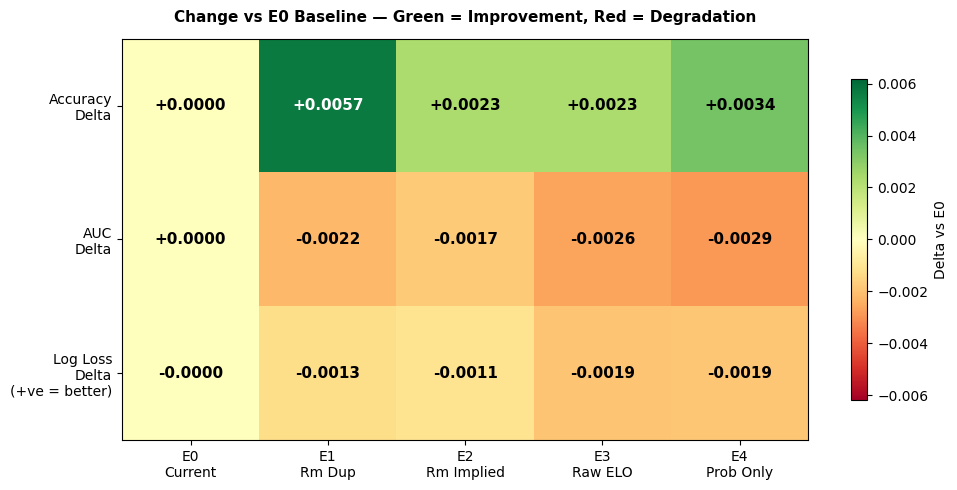

Heatmap saved.


In [11]:
import matplotlib.colors as mcolors

delta_metrics = ['acc_delta', 'auc_delta', 'll_delta']
delta_labels  = ['Accuracy Delta', 'AUC Delta', 'Log Loss Delta (neg=better)']

# For log_loss, negative delta = improvement
delta_data = results_df[delta_metrics].copy()
delta_data['ll_delta'] = -delta_data['ll_delta']  # flip: positive now means improvement

fig, ax = plt.subplots(figsize=(10, 5))

vmax = delta_data.abs().values.max() + 0.0005
im = ax.imshow(delta_data.values.T, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_yticks(range(3))
ax.set_yticklabels(['Accuracy\nDelta', 'AUC\nDelta', 'Log Loss\nDelta\n(+ve = better)'], fontsize=10)
ax.set_title('Change vs E0 Baseline — Green = Improvement, Red = Degradation',
             fontsize=11, fontweight='bold', pad=12)

for i in range(len(results_df)):
    for j in range(3):
        val = delta_data.values[i, j]
        ax.text(i, j, f'{val:+.4f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='black' if abs(val) < vmax * 0.6 else 'white')

plt.colorbar(im, ax=ax, label='Delta vs E0', shrink=0.8)
plt.tight_layout()
plt.savefig('../reports/ablation_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

## Cell 12 — Final Decision & Recommendation

In [12]:
print('=' * 65)
print('  ABLATION TEST — FINAL DECISION')
print('=' * 65)

best_exp     = results_df['roc_auc'].idxmax()
auc_delta    = results_df.loc[best_exp, 'auc_delta']
acc_delta    = results_df.loc[best_exp, 'acc_delta']
feats_removed = results_df.loc['E0_current', 'n_features'] - results_df.loc[best_exp, 'n_features']

print(f'\n  Best configuration  : {best_exp}')
print(f'  Features            : {results_df.loc[best_exp, "n_features"]} (removed {feats_removed} vs E0)')
print(f'  AUC vs E0           : {auc_delta:+.4f}')
print(f'  Accuracy vs E0      : {acc_delta:+.4f}')
print(f'  Away Recall         : {results_df.loc[best_exp, "away_recall"]:.4f}')
print(f'  Home Recall         : {results_df.loc[best_exp, "home_recall"]:.4f}')

print('\n  --- Interpretation ---')
if auc_delta > 0.002:
    verdict = 'CLEAR IMPROVEMENT'
    action  = f'Switch to {best_exp} immediately. Retrain training.ipynb with this feature set.'
elif auc_delta >= -0.001:
    verdict = 'EQUIVALENT PERFORMANCE — SIMPLER IS BETTER'
    action  = f'Use {best_exp}. Same accuracy, fewer features = less noise = more robust.'
else:
    verdict = 'MINIMAL LOSS — REVIEW MANUALLY'
    action  = 'Small AUC drop. Check if other metrics (Brier, Away Recall) compensate.'

print(f'\n  Verdict : {verdict}')
print(f'  Action  : {action}')

# Print the exact code change needed for training.ipynb
print('\n' + '=' * 65)
print('  CODE CHANGE FOR training.ipynb (Cell 10)')
print('=' * 65)

features_to_remove = [f for f in FEATURES_E0 if f not in experiments[best_exp]]
if features_to_remove:
    remove_str = str(features_to_remove)
    print(f'\n  Add this line after ALL_FEATURES is built:')
    print(f'\n  ALL_FEATURES = [f for f in ALL_FEATURES')
    print(f'                  if f not in {remove_str}]')
    print(f'\n  Features removed: {features_to_remove}')
else:
    print('\n  No changes needed — E0_current is the best configuration.')

print('\n' + '=' * 65)
print('  FULL RESULTS SUMMARY')
print('=' * 65)
summary_cols = ['n_features', 'accuracy', 'roc_auc', 'log_loss', 'brier',
                'away_recall', 'home_recall', 'acc_delta', 'auc_delta']
print(results_df[summary_cols].to_string())

  ABLATION TEST — FINAL DECISION

  Best configuration  : E0_current
  Features            : 69 (removed 0 vs E0)
  AUC vs E0           : +0.0000
  Accuracy vs E0      : +0.0000
  Away Recall         : 0.4937
  Home Recall         : 0.7562

  --- Interpretation ---

  Verdict : EQUIVALENT PERFORMANCE — SIMPLER IS BETTER
  Action  : Use E0_current. Same accuracy, fewer features = less noise = more robust.

  CODE CHANGE FOR training.ipynb (Cell 10)

  No changes needed — E0_current is the best configuration.

  FULL RESULTS SUMMARY
                   n_features  accuracy  roc_auc  log_loss  brier  away_recall  home_recall  acc_delta  auc_delta
experiment                                                                                                       
E0_current                 69    0.6382   0.7092    0.6141 0.2141       0.4937       0.7562     0.0000     0.0000
E1_remove_dup              68    0.6439   0.7069    0.6153 0.2147       0.4911       0.7686     0.0057    -0.0022
E2_remo

## Cell 13 — Save Results to CSV

In [13]:
os.makedirs('../reports', exist_ok=True)
results_df.to_csv('../reports/ablation_results.csv')
print('Results saved to ../reports/ablation_results.csv')
print('\nFinal table:')
print(results_df[['n_features','accuracy','roc_auc','log_loss',
                   'away_recall','home_recall','acc_delta','auc_delta']].to_string())

Results saved to ../reports/ablation_results.csv

Final table:
                   n_features  accuracy  roc_auc  log_loss  away_recall  home_recall  acc_delta  auc_delta
experiment                                                                                                
E0_current                 69    0.6382   0.7092    0.6141       0.4937       0.7562     0.0000     0.0000
E1_remove_dup              68    0.6439   0.7069    0.6153       0.4911       0.7686     0.0057    -0.0022
E2_remove_implied          67    0.6405   0.7074    0.6152       0.4987       0.7562     0.0023    -0.0017
E3_raw_elo_only            65    0.6405   0.7065    0.6160       0.4911       0.7624     0.0023    -0.0026
E4_prob_only               65    0.6416   0.7063    0.6159       0.4785       0.7748     0.0034    -0.0029
